# Aula 7

# Transferência de Estilo

### Eduardo Lobo Lustosa Cabral

Nessa aula uma RNA pré-treinada é utilizada para alterar o estilo de uma imagem. A rede pré-treinada que utilizada é a VGG19 que está disponível no Keras.

Nessa aula iremos fazer:

- Implementar o método de transferência de estilo;
- Gerar imagens com novos estilos de arte;
- Os algoritmos estudados até o momento minimizam uma função de custo para obter os parâmetros de uma RNA. Na transferência de estilo uma função de custo é minimizada para obter os valores dos pixels de uma imagem.

O método de transferência de estilo usado nesse trabalho foi criado por Gatys et al. (2015) (https://arxiv.org/abs/1508.06576).

O algortimo implementado nesse notebook foi desenvolvido por: https://github.com/tensorflow/models/blob/master/research/nst_blogpost/4_Neural_Style_Transfer_with_Eager_Execution.ipynb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/T6 - Transferência de estilo
!ls

/content/drive/MyDrive/T6 - Transferência de estilo
images


## 1 - Definição do problema

A transferência de estilo realizada por uma rede neural (NST) é uma das técnicas mais interessantes de "deep-learning". Como visto em aula a NST mescla duas imagens, a imagem de "conteúdo" (**C**) e a imagem de "estilo" (**S**), para criar uma nova imagem "gerada" (**G**). A imagem gerada **G** combina o "conteúdo" da imagem **C** com o "estilo" da imagem **S**.

Nessa aula, como primeiro exemplo, iremos gerar uma imagem do museu do Louvre em Paris (imagem de conteúdo **C**) com o estilo de uma pintura de Claude Monet, líder do movimento impressionista (imagem de estilo **S**).

A transferência de estilo neural (NST) usa uma rede convolucional previamente treinada. Como já visto em aula, a idéia de usar uma rede pré-treinada em uma tarefa diferente e aplicá-la a uma nova tarefa é chamada de transferência de aprendizado.

Seguindo o trabalho original do NST (https://arxiv.org/abs/1508.06576) usaremos a rede VGG19, que é uma versão de 19 camadas da rede VGG. A VGG19 foi treinada no banco de dados ImageNet que possui milhões de imagens e, portanto, é capaz de reconhecer uma grande variedade de características de baixo nível (presentes nas camadas iniciais da RNA) e de alto nível (presentes nas camadas mais profundas).

## 2 - Preparação e inicialização do ambiente  e das imagens

### Importação das bibliotecas

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import time

import tensorflow as tf
from tensorflow.python.keras import models
from tensorflow.python.keras import losses
from tensorflow.python.keras import layers
from tensorflow.python.keras import backend as K

### Visualização das imagens de entrada

As imagens de conteúdo e de estilo são mostradas a seguir. O que queremos é criar uma nova imagem com o conteúdo da imagem de "conteúdo" e com o estilo da imagem de "estilo".

In [ ]:
# Definição de variáveis globais e visualização da simagens

content_path = 'images/louvre.jpg'
style_path = 'images/monet_800600.jpg'

In [ ]:
# Função para ler imagem e transformar em um array do TensorFlow
def load_img(path_to_img):
    max_dim = 512
    img = Image.open(path_to_img)
    long = max(img.size)
    scale = max_dim/long
    img = img.resize((round(img.size[0]*scale), round(img.size[1]*scale)), Image.BICUBIC)
    img = tf.keras.utils.img_to_array(img)

    # Inclui eixo dos exemplos
    img = np.expand_dims(img, axis=0)
    return img

In [ ]:
# Função para mostrar imagem
def imshow(img, title=None):
    # Remove o eixo dos exemplos
    out = np.squeeze(img, axis=0)

    # Transforma pixels em inteiros
    out = out.astype('uint8')
    plt.imshow(out)
    if title is not None:
        plt.title(title)
        plt.imshow(out)

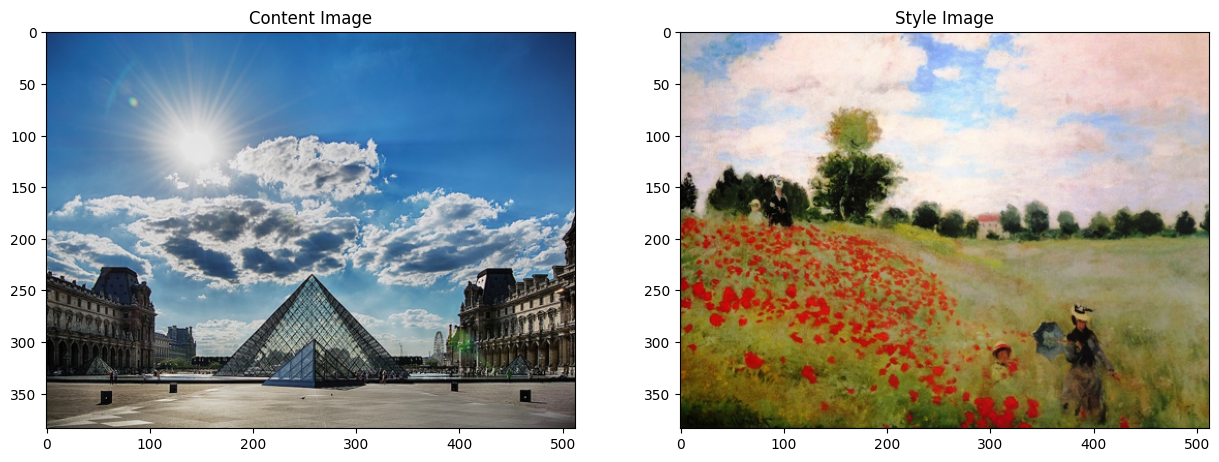

In [ ]:
# Mostra as imagens de conteúdo e de estilo
plt.figure(figsize=(15,15))

content = load_img(content_path).astype('uint8')
style = load_img(style_path).astype('uint8')

plt.subplot(1, 2, 1)
imshow(content, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style, 'Style Image')
plt.show()

## 2 - RNA convolucional base

Como já visto as RNAs VGG16 e VGG19 foram desenvolvidas para classificação de múltiplas classes com 1.000 classes. Ela são utilizadas para reconhecimento de objetos em imagens. A arquitetura das VGGs é muito simples, sendo composta pela repetição de camadas convolucionais formando blocos. Cada bloco é composto por duas ou três camadas convolucionais, com filtros 3x3, stride = 1 e “same convolution”, seguida por uma camada de max-pooling, com janela 2x2 e stride = 2. A VGG19 mantém praticamente o mesmo padrão em todos os blocos dobrando o número de filtros a cada bloco. Apesar da VGG19 possuir muitos parâmetros, cerca de 143 milhões, ela é muito simples.


### 2.1 Importação da RNA VGG19

O TensorFlow/keras possui na sua base de dados a RNA VGG19 treinada com o banco de imagens imagenet. A célula abaixo carregua a VGG19 usando o comando do TensorFlow `keras.applications.vgg19.VGG19`.

In [ ]:
# Carregar e salvar a VGG19 na rna-base
vgg = tf.keras.applications.vgg19.VGG19(include_top=False, weights='imagenet')
vgg.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Preparação dos dados para a rede VGG19

Precisamos criar funções que permitem carregar e pré-processar imagens para serem utilizadas pela rede VGG19. Devemos realizar o mesmo pré-processamento utilizado nas imagens processadas pela rede VGG19. A rede VGG19 é treinada com imagens onde cada canal RGB é normalizado usando as seguintes médias = [103,939, 116,779, 123,68].

A célula abaixo define a função que realiza a normalização das imagens de acordo com o esperado pela VGG19. A função `tf.keras.applications.vgg19.preprocess_input()` já está pronta para fazer essa normalização.

In [ ]:
from tensorflow.keras.applications import vgg19

def load_and_process_img(path_to_img):
    img = load_img(path_to_img)
    img = vgg19.preprocess_input(img)
    return img

Para visualizar os resultados da nossa transferência de estilo, temos que executar a etapa inversa de pré-processamento. Além disso, como a imagem gerada pode ter valores entre −∞  e  ∞, precisamos incluir um limite para manter os valores dentro do intervalo de 0 a 255. A função `deprocess_img` realiza esse cálculo .

In [ ]:
def deprocess_img(processed_img):
    x = processed_img.copy()
    if len(x.shape) == 4:
        x = np.squeeze(x, 0)

    assert len(x.shape) == 3, ("Entrada deve ser uma imagem de"
                               "dimensão [1, altura, largura, canal]")
    if len(x.shape) != 3:
        raise ValueError("Entrada inválida para transformar")

    # Realiza o inverso da normalização das imagens
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]

    x = np.clip(x, 0, 255).astype('uint8')
    return x

## 3 - Definição das representações de conteúdo e estilo

Como visto, para obter as representações de conteúdo e estilo de uma imagem, devemos escolher algumas camadas intermediárias da rede convolucional. Na medida em que aprofundamos na rede convolucional, as camadas intermediárias representam características cada vez mais elaboradas. As saídas dessas camadas intermediárias são necessárias para definir a representação do conteúdo e do estilo das imagens.

As saídas das camadas intermediárias de uma rede convulocional, que foi pré-treinada para uma tarefa de classificação, permite definir representações de estilo e conteúdo. De forma geral, isso pode ser explicado pelo fato de que para uma rede executar a classificação de uma imagem, ela deve ser capaz de "entender" a imagem. Isso envolve processar os pixels da imagem e construir uma representação interna que permite uma compreensão complexa das caracteríticas presentes na imagem. As redes neurais convolucionais são capazes de capturar as invariâncias e as características que definem classes (por exemplo, gatos versus cães) e que não dependem de ruídos de fundo e outras sutilezas. Assim, qualquer camada convolucional de uma RNA convolucional serve como um extrator de caracteríticas, portanto, ao acessar as saídas de camadas intermediárias, podemos descrever o conteúdo e o estilo da imagem processada.


### 3.1 Definição das camadas de conteúdo e de estilo

As camadas da VGG19 que serão usadas para definir o conteúdo e o estilo das imagens são as seguintes:

- Camada de conteúdo: `block5_conv2`
- Camadas de estilo: `block1_conv1`, `block2_conv1`, `block3_conv1`, `block4_conv1` e `block5_conv1`.

In [ ]:
# Camada de conteúdo
content_layers = ['block5_conv2']

# Camdas de estilo (lista com os nomes das camadas utilizadas)
style_layers = ['block1_conv1','block2_conv1','block3_conv1','block4_conv1','block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

print('Camadas de conteúdo:', content_layers)
print('Camadas de estilo:', style_layers)

Camadas de conteúdo: ['block5_conv2']
Camadas de estilo: ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']


## 4 - Construção do modelo

Para construir o modelo usado para a transferência de estilo devemos carregar a VGG19, fornecer a imagem de entrada e definir os tensores de saída. Isso permite extrair os mapas de caracteríticas de conteúdo e de estilo e obter a imagem gerada.

Usamos a VGG19, conforme sugerido no trabalho original de transferência de estilo. Uma das vantagens da VGG19 é que é uma RNA  relativamente simples (comparada as redes ResNet, Inception etc.), assim, os mapas de características funcionam melhor para a transferência de estilos.

Para acessar as camadas intermediárias correspondentes aos mapas de caracterísitcas de estilo e conteúdo, obtemos as saídas correspondentes dessas camadas e definimos nosso modelo com as ativações das saídas desejadas.

In [ ]:
# def get_model():
#     """ Cria modelo com acesso às camadas intermediárias.

#     Retorna:
#         Modelo do Keras que recebe uma imagem e calcula o estilo e o conteúdo de camadas intremediárias.
#     """

#     # Carrega a VGG19 pré-treinada
#     vgg = tf.keras.applications.vgg19.VGG19(include_top=False, weights='imagenet')
#     vgg.trainable = False

#     # Apresentar o sumario da VGG19 para forçar o construir o modelo e inicializar os parâmetros
#     vgg.summary()

#     # Determina camada de entrada
#     input = vgg.input

#     # Determina saídas que correspondem às camadas de conteúdo e de estilo
#     # Apply keras.layers.Layer to the outputs to ensure _keras_history is set correctly.
#     style_outputs = [layers.Layer(name=name)(vgg.get_layer(name).output) for name in style_layers]  # Wrap layer outputs with a Keras Layer to set _keras_history
#     content_outputs = [layers.Layer(name=name)(vgg.get_layer(name).output) for name in content_layers]  # Wrap layer outputs with a Keras Layer to set _keras_history
#     model_outputs = style_outputs + content_outputs

#     # Cria modelo
#     model = models.Model(input, model_outputs)

    # return model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def get_model(style_layers, content_layers):
    """ Cria modelo com acesso às camadas intermediárias.

    Retorna:
        Modelo do Keras que recebe uma imagem e calcula o estilo e o conteúdo de camadas intermediárias.
    """

    # Carrega a VGG19 pré-treinada
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    # Apresentar o sumário da VGG19 para forçar a construção do modelo e inicializar os parâmetros
    # vgg.summary()

    # Determina camada de entrada
    model_input = vgg.input

    # Determina saídas que correspondem às camadas de conteúdo e de estilo
    style_outputs = [vgg.get_layer(name).output for name in style_layers]
    content_outputs = [vgg.get_layer(name).output for name in content_layers]

    # Combina saídas de estilo e conteúdo
    model_outputs = style_outputs + content_outputs

    # Cria o modelo final
    model = models.Model(inputs=model_input, outputs=model_outputs)

    return model

In [ ]:
# style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1']  # Exemplo de camadas de estilo
# content_layers = ['block5_conv2']  # Exemplo de camada de conteúdo

model = get_model(style_layers, content_layers)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 15,304,768 (58.38 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 15,304,768 (58.38 MB)

### Estatísticas das saídas das camadas

É possível calcular algumas estatísticas das ativações das camadas escolhidas para definir conteúdo e estilo. Como exemplo, o código da  célula abaixo calcula as estatísticas das ativações das camadas escolhidas para definir estilo da imagem de estilo.

In [ ]:
# Cria a RNA usando a função get_model definida acima
model = get_model(style_layers, content_layers)

# Carrega imagem de estilo
style_image = load_and_process_img(style_path)

# Executa o modelo (RNA) com a imagem de estilo para calcular as ativações das camadas escolhidas
style_outputs = model(style_image)

# Calcula alguns valores estatísticos das camadas da lista "style_layers"
for name, output in zip(style_layers, style_outputs):
    print(name)
    print("  shape: ", output.numpy().shape)
    print("  min: ", output.numpy().min())
    print("  max: ", output.numpy().max())
    print("  mean: ", output.numpy().mean())
    print()

block1_conv1
  shape:  (1, 384, 512, 64)
  min:  0.0
  max:  549.16797
  mean:  18.515154

block2_conv1
  shape:  (1, 192, 256, 128)
  min:  0.0
  max:  2957.358
  mean:  98.652275

block3_conv1
  shape:  (1, 96, 128, 256)
  min:  0.0
  max:  7075.3394
  mean:  96.52762

block4_conv1
  shape:  (1, 48, 64, 512)
  min:  0.0
  max:  13152.836
  mean:  394.40784

block5_conv1
  shape:  (1, 24, 32, 512)
  min:  0.0
  max:  1833.0842
  mean:  28.595068



## 5 - Funções de custo de conteúdo e estilo


### 5.1 Função de custo de conteúdo

A função de custo de conteúdo é realmente bastante simples. Passamos como entradas para a RNA convolucional a imagem de conteúdo desejada e a imagem gerada (uma de cada vez). Isso retorna as saídas da camada intermediária definida como camada de conteúdo para ambas as imagens. Então, simplesmente tomamos a distância euclidiana entre as duas representações intermediárias dessas imagens.

Mais formalmente, a função de custo de conteúdo descreve a distância do conteúdo da imagem gerada **G**, com o conteúdo da imagem de conteúdo **C**. Seja $C_{nn}$ a RNA convolucional VGG19 pré-treinada e seja **X** uma imagem qualquer, então $C_{nn}(X)$ é a rede alimentada pela imagem **X**. Seja $a^{[l]C} \in C_{nn}(C)$ e $a^{[l]G} \in C_{nn}(G)$ as saídas da camada intermediária $l$ da RNA com entradas **C** e **G** respectivamente. A distância entre $a^{[l]C}$ e $a^{[l]G}$, ou seja, o custo de conteúdo, é formalmente definida como sendo:

$$J_C(C, G) = \frac {1} {2} \sum_{i, j, k} (a_{i,j,k}^{[l]C} - a_{i,j,k}^{[l]G})^2$$


### 5.2 Função de custo de conteúdo

O custo de conteúdo é definido como sendo o erro entre as saídas da `content_layer` das imagens de conteúdo e gerada, conforme definido na equação acima.

In [ ]:
# Função de custo de conteúdo
def get_content_loss(base_content, target):
    JC = tf.reduce_mean(tf.square(base_content - target))/2
    return JC

Vamos testar a função de custo conteúdo para verificar se foi implmentada corretamente.

In [ ]:
np.random.seed(3)
aC = np.random.random((3,3))
aG = np.random.random((3,3))
JC = get_content_loss(aC, aG)
print('Custo de conteúdo=', JC.numpy())

Custo de conteúdo= 0.08068334147758457


### 5.3 Matriz de Gram

A fórmula para calcular a matriz de Gram de uma matriz **A** é dada por:

$$M = AA^T$$


A função da célula abaixo calcula a matriz de Gram.

In [ ]:
def gram_matrix(input_tensor):
    # Redimensiona tensor para para ter 2 eixos (linhas*colunas e canais)
    channels = int(input_tensor.shape[-1])
    A = tf.reshape(input_tensor, [-1, channels])
    gram = tf.matmul(A, A, transpose_a=True)
    return gram

### 5.4 Função de custo de estilo

O cálculo da função de custo de estilo é um pouco mais complexo. Desta vez a rede VGG19 recebe como entradas as imagens de conteúdo **C** e de estilo **S**. No entanto, em vez de comparar as saídas das camadas intermediárias comparamos as matrizes Gram das duas saídas.

Matematicamente, descrevemos a perda de estilo entre a imagem de conteúdo, **C**, e a imagem do estilo, **S**, como sendo a distância entre a representação do estilo (matrizes de Gram) dessas duas imagens.

Descrevemos a representação do estilo de uma imagem como sendo a correlação entre as saídas de diferentes filtros fornecida pela matriz de Gram da camada $l$, **M**$^{[l]}$, onde cada elemento dessa matriz, $m^{[l]}_{i,j}$, é o produto escalar entre as saídas dos filtros $i$ e $j$ da camada $l$.

A contribuição de cada camada no custo de estilo é descrita por:

$$J^{[l]}_S(S,G) = \frac {1} {4(n^{[l]}_H n^{[l]}_W n^{[l]}_C)^2}) \sum_ {i, j} (m^{[l]S}_{ij} - m^{[l]G}_{ij})^2 \tag{1}$$

onde $m^{[l]S}_{ij}$ e $m^{[l]G}_{ij}$ são respectivamente as representações de estilo da camada $l$ de **S** e **G**, $n^{[l]}_C$ é o número de filtros (canais) da camada $l$, cada um com dimensão  $n^{[l]}_H$ por $n^{[l]}_W$.

Assim, a perda total de estilo é obtida somando as perdas em cada uma das camadas usadas para descrever o estilo, ou seja:

$$J_S(S,G) = \sum_{l \in L} \lambda^{[l]} J^{[l]}_S(S,G) \tag{2}$$

Observe que ponderamos a contribuição da perda de cada camada pelo fator $\lambda^{[l]}$. No nosso caso, iremos ponderar cada camada igualmente por $\lambda^{[l]} = \frac{1}{|L|}$.


### 5.5 Função de custo de estilo da camada $l$

Para calcular a função de custo de estilo vamos primeiramente criar uma função para calcular a função de custo de estilo das imagens de estilo e gerada da camada $l$, conforme definido na equação (1) acima.

Observe que como a imagem de estilo não muda durante o cálculo, então, a matriz de Gram dessa imagem não precisa ser calculada a todo momento, bastando calculá-la no início do processo. Dessa forma, a função custo de estilo recebe as saídas das camadas definidas para calcular o estilo da imagem gerada (`base_style`) e a matriz de Gram da imagem de estilo.

In [ ]:
# Função de custo de estilo de uma camada
def get_style_loss(base_style, gram_target):
    # base_style = saídas das camadas de "estilo" referentes à imagem gerada
    # gram_target = matriz de Gram calculada para cada camada de "estilo" referente à imagem de estilo

    # Dimensões da camada de estilo
    height, width, channels = base_style.get_shape().as_list()

    # Matriz de Gram
    gram_style = gram_matrix(base_style)

    # Função de custo de estilo para uma camada
    JS = tf.reduce_mean(tf.square(gram_style - gram_target)) / (4. * (channels * width * height)**2)

    return JS

Vamos verificar se a sua função de custo de estilo foi implementada corretamente.

In [ ]:
np.random.seed(3)
MC = tf.Variable(np.random.random((3,3,3)), dtype=tf.float32)
MG = np.random.random((3,3,3))
JS = get_style_loss(MC, MG)
print(JS.numpy())

0.00083592156


### 5.6 Cálculo das características das imagens de conteúdo e de estilo

Precisamos calcular as características das imagens de conteúdo e de estilo para serem usadas como representações de conteúdo e estilo do nosso modelo. Para isso, vamos definir a função `get_feature_representations` que calcula essas características.

A função da célula abaixo calcula as características das imagens de conteúdo e de estilo usando a VGG19 recebida no objeto `model` e a "path" para as imagens de conteúdo e de estilo.

In [ ]:
# Cálculo das representações de conteúdo e de estilo

def get_feature_representations(model, content_path, style_path):
    """Essa função calcula as representações de conteúdo e de estilo

    Essa função simplesmente carrega e processa as imagens de conteúdo e de estilo
    e depois processa essas imagens para calcular as saídas das camadas intermediárias.

    Argumentos:
        model: VGG19
        content_path: arquivo da imagem de conteúdo
        style_path: arquivo da imagem de estilo

    Retorna:
        Características de estilo e de conteúdo
    """

    # Usando a função load_and_process_img carrega as imagens de conteùdo e de estilo
    content_image = load_and_process_img(content_path)
    style_image = load_and_process_img(style_path)

    # Usando a RNA VGG19 recebida no objeto "model", calcula as caracteríticas das imagens de conteúdo e de estilo
    style_outputs = model(style_image)
    content_outputs = model(content_image)

    # Obtém as representações de conteúdo e de estilo
    style_features = [style_layer[0] for style_layer in style_outputs[:num_style_layers]]
    content_features = [content_layer[0] for content_layer in content_outputs[num_style_layers:]]

    return style_features, content_features

### 5.7 Função de custo total

A função `compute_loss` implementada na célula abaixo calcula a função de custo total, dada abaixo, para realizar a transferência de estilo.

$$J(G) = \alpha J_C(S,G) + \beta J_S(S,G)$$

onde $\alpha$ é o peso do custo de conteúdo e $\beta$ é o peso do custo de estilo.

In [ ]:
def compute_loss(model, loss_weights, init_image, gram_style_features, content_features):
    """
    Argumentos:
        model: VGG19
        loss_weights: pesos de ponderação ara cada contribuição da função de custo
        init_image: imagem inicial que é atualizada durante o processo de otimização
        gram_style_features: matriz de gram pré-calculada da imagem de estilo
        content_features: saída da camada de conteúdo

    Retorna:
        total loss, style loss e content loss
    """

    style_weight, content_weight = loss_weights

    # Calcula saídas das camadas intermediárias da imagem incial
    model_outputs = model(init_image)

    # Define características de estilo e conteúdo
    style_output_features = model_outputs[:num_style_layers]
    content_output_features = model_outputs[num_style_layers:]

    # Inicializa custos de estilo e conteúdo
    style_score = 0
    content_score = 0

    # Calcula custo das camadas de estilo e soma a contribuição de cada uma
    weight_per_style_layer = 1.0 / float(num_style_layers)
    for target_style, comb_style in zip(gram_style_features, style_output_features):
        style_score += weight_per_style_layer * get_style_loss(comb_style[0], target_style)

    # Acumula custo de conteúdo de todas as camadas e soma contribuições
    weight_per_content_layer = 1.0 / float(num_content_layers)
    for target_content, comb_content in zip(content_features, content_output_features):
        content_score += weight_per_content_layer* get_content_loss(comb_content[0], target_content)

    # Multiplica custo de conteúdo e de estilo pelos pesos de ponderaçãp
    style_score *= style_weight
    content_score *= content_weight

    # Calcula custo total
    loss = style_score + content_score

    return loss, style_score, content_score

## 6 - Transferência de estilo entre as imagens

Vamos usar o otimiizador Adam para minimizar a função de custo total. Atualizamos iterativamente a imagem de saída (imagem gerada) para minimizar a função de custo total. Na transferência de estilo não atualizamos os pesos associados à nossa rede como de costume, mas treinamos a imagem de entrada para minimizar a perda, conforme a equação abaixo.

$$G = G - \frac{\partial J(G)}{\partial G}$$


Para fazer esse cálculo precisamos calcular além da função de custo total o seu gradiente em relação aos pixels da imagem gerada.


### 6.1 Cálculo do gradiente

Execute a célula abaixo para definir a função `compute_grads` que calcula o gradiente da função de custo total em relação aos pixels da imagem gerada. Essa função utliza a função do TensorFlow `tf.GradientTape()`(https://www.tensorflow.org/api_docs/python/tf/GradientTape) para calcular o gradiente $\frac{\partial J(G)}{\partial G}$ e a função `compute_loss` (definda acima) para calcular o custo total $J(G)$.

A função `tf.GradientTape()` calcula automaticamente as derivadas usando as operações definidas para calcular a função de custo total, facilitando a implementação do processo.

In [ ]:
def compute_grads(cfg):
    # Calcula custo total no contexto de GradientTape
    with tf.GradientTape() as G:
        all_loss = compute_loss(**cfg)

    # Calcula gradientes da função de custo em relação aos pixels da imagem gerada
    total_loss = all_loss[0]
    grad = G.gradient(total_loss, cfg['init_image'])

    # retorna gradiente e custo
    return grad, all_loss

### 6.2 Juntando todas as funções

A célula abaixo define a função que implementa o método iterativo da transferência de estilo chamando as funções definidas anteriormente.

Observe que o fatores de ponderação das funções de custo de conteúdo e de estilo padrão são ambos iguais a 100.

In [ ]:
import IPython.display

def run_style_transfer(content_path, style_path, num_iterations=1, content_weight=100, style_weight=100):
    # Não é necessário treinar nenhum modelo, assim, definimos todos os parâmetros como não treináveis
    model = get_model(style_layers, content_layers)
    for layer in model.layers:
        layer.trainable = False

    # Calcula as representações de estilo e conteúdo (camadas intermediárias selecionadas)
    style_features, content_features = get_feature_representations(model, content_path, style_path)

    # Calcula matriz de Gram
    gram_style_features = [gram_matrix(style_feature) for style_feature in style_features]

    # Inicializa imagem gerada com a imagem de conteúdo
    init_image = load_and_process_img(content_path)
    init_image = tf.Variable(init_image, dtype=tf.float32)

    # Cria otimizador Adam
    opt = tf.optimizers.Adam(learning_rate=5.0)

    # Para visualização de imagens intermediárias
    iter_count = 1

    # Inicializa custo e imagem de saída
    best_loss, best_img = float('inf'), None

    # Cria config para ser usado na função compute_grads
    loss_weights = (style_weight, content_weight)
    cfg = {'model': model,'loss_weights': loss_weights,'init_image': init_image,'gram_style_features': gram_style_features,'content_features': content_features}

    # Parâmetros para visualização
    num_rows = 2
    num_cols = 5
    display_interval = num_iterations/(num_rows*num_cols)
    start_time = time.time()
    global_start = time.time()

    # Determina valores máximo e mínimo dos pixels da imagem
    norm_means = np.array([103.939, 116.779, 123.68])
    min_vals = -norm_means
    max_vals = 255 - norm_means

    # Inicializa imagens e histórico do processo de treinamento
    imgs = []
    history = np.zeros(num_iterations)

    for i in range(num_iterations):
        # Calcula gradiente da função de custo
        grads, all_loss = compute_grads(cfg)

        # Separa os custos de estilo e conteúdo
        loss, style_score, content_score = all_loss

        # Aplica gradiente na imagem gerada
        opt.apply_gradients([(grads, init_image)])

        # Corta valores dos pixels menor que mínimo e maior que máximo
        clipped = tf.clip_by_value(init_image, min_vals, max_vals)
        init_image.assign(clipped)

        # Determina instante de tempo
        end_time = time.time()

        # Salva imagem gerada se novo valor da função de custo for menor que o anterior
        if loss < best_loss:
            # Atualiza imagem a partir da função de custo total
            best_loss = loss
            best_img = deprocess_img(init_image.numpy())

        # Mostra imagem e resultados dos custos
        if i % display_interval== 0:
            start_time = time.time()

            # Apresenta imagem
            plot_img = init_image.numpy()
            plot_img = deprocess_img(plot_img)
            imgs.append(plot_img)
            IPython.display.clear_output(wait=True)
            IPython.display.display_png(Image.fromarray(plot_img))
            print('Iteration: {}'.format(i))
            print('Total loss: {:.4e},style loss: {:.4e},content loss: {:.4e},time: {:.4f}s'.format(loss, style_score, content_score, time.time() - start_time))

        # Guardo custo total na história do processo de treinamento
        history[i] = loss

    # Mostra resultado final
    print('Total time: {:.4f}s'.format(time.time() - global_start))
    IPython.display.clear_output(wait=True)
    plt.figure(figsize=(14,4))
    for i,img in enumerate(imgs):
        plt.subplot(num_rows,num_cols,i+1)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])

    return best_img, best_loss, history

### 6.3 Teste do algoritmo

Vamos testar e visualizar o resultado do método de transferência de estilo usando 200 iterações.

In [ ]:
best_1, best_loss_1, history = run_style_transfer(content_path,style_path, num_iterations=200)
print('Custo =', best_loss_1)

In [ ]:
# Cria vetor de épocas e faz o gráfico do custo em função das épocas
tempo = range(1, len(history) + 1)
plt.figure(figsize=(10, 5))
plt.plot(tempo, history, 'bo')
plt.title('Valor da função de custo')
plt.xlabel('Iteração')
plt.ylabel('Custo')
plt.grid()
plt.show()

#### Visualização da imagem resultante

In [ ]:
# Cria função para visualizar resultados
def show_results(best_img, content_path, style_path, show_large_final=True):
    plt.figure(figsize=(10, 5))
    content = load_img(content_path)
    style = load_img(style_path)

    plt.subplot(1, 2, 1)
    imshow(content, 'Content Image')

    plt.subplot(1, 2, 2)
    imshow(style, 'Style Image')

    if show_large_final:
        plt.figure(figsize=(10, 10))

        plt.imshow(best_img)
        plt.title('Output Image')
        plt.show()

show_results(best_1, content_path, style_path)

## 7 - Testes com alterações dos parâmetros

A função de custo total consiste de uma média ponderada entre as parcelas referentes ao conteúdo e ao estilo, conforme a seguinte equação:

$$J(G) = \alpha J_C(S,G) + \beta J_S(S,G)$$

Vamos verificar o que acontece se alterarmos os valores dos pesos das parcelas da função de custo relativas ao conteúdo ($\alpha$) e ao estilo ($\beta$).


### 7.1 Primeira alteração dos pesos das parcelas de conteúdo e estilo

Vamos diminuir o peso do custo de estilo para 20 e manter o peso do custo de conteúdo em 100 e executar novamente a função `run_style_transfer`. Observe que $\alpha$ = `content_weight` e $\beta$ = `style_weight`.


In [ ]:
# Teste de transferência de estilo com novos parâmetros
best_2, best_loss_2, history2 = run_style_transfer(content_path,style_path, num_iterations=200, content_weight=100, style_weight=20)

print('Custo =', best_loss_2)

In [ ]:
# Cria vetor de épocas e faz o gráfico da função de custo total em função das épocas
tempo = range(1, len(history2) + 1)
plt.figure(figsize=(10, 5))
plt.plot(tempo, history2, 'bo')
plt.title('Valor da função de custo')
plt.xlabel('Iteração')
plt.ylabel('Custo')
plt.grid()
plt.show()

show_results(best_2, content_path, style_path)

### 7.2 Segunda alteração dos pesos das parcelas de conteúdo e estilo

Vamos aumentar o peso do custo de estilo para 500 mantendo o peso do custo de conteúdo em 100 e executar novamente a função `run_style_transfer`.

In [ ]:
# Teste de transferência de estilo com novos parâmetros
best_3, best_loss_3, history3 = run_style_transfer(content_path,style_path, num_iterations=200, content_weight=100, style_weight=500)

print('Custo =', best_loss_3)

In [ ]:
# Cria vetor de épocas e faz o gráfico da função de custo total em função das épocas
tempo = range(1, len(history3) + 1)
plt.figure(figsize=(10, 5))
plt.plot(tempo, history3, 'bo')
plt.title('Valor da função de custo')
plt.xlabel('Iteração')
plt.ylabel('Custo')
plt.grid()
plt.show()

show_results(best_3, content_path, style_path)

### 7.3 Alteração das camadas usadas para descrever conteúdo e estilo

Vamos manter ambos os pesos do custo de estilo e de conteúdo iguais a 100 e alterar as camadas utilizadas para definir o conteúdo e o estilo das imagens.

Para representar o conteúdo vamos usar as camadas `block5_conv3`.

Para representar o estilo vamos usar as camadas `block1_conv2`, `block2_conv2`, `block3_conv2`, `block4_conv2` e `block5_conv2`.


In [ ]:
# Camada de conteúdo
content_layers = ['block5_conv3']

# Camadas de estilo. Inclua uma lista com os nomes das camadas
style_layers = ['block1_conv2','block2_conv2','block3_conv2','block4_conv2','block5_conv2']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

print('Camadas de conteúdo:', content_layers)
print('Camadas de estilo:', style_layers)

In [ ]:
# Executa a função de transferência de estilo
best_4, best_loss_4, history4 = run_style_transfer(content_path,style_path, num_iterations=200, content_weight=100, style_weight=100)

print('Custo =', best_loss_4)

In [ ]:
# Cria vetor de épocas e faz o gráfico da função de custo total em função das épocas
tempo = range(1, len(history4) + 1)
plt.figure(figsize=(10, 5))
plt.plot(tempo, history4, 'bo')
plt.title('Valor da função de custo')
plt.xlabel('Iteração')
plt.ylabel('Custo')
plt.grid()
plt.show()

show_results(best_4, content_path, style_path)

## Conclusões:

1. Note que diminuir o peso da parcela do estilo na função de custo a imagem resultante vai parecer mais com a imagem de conteúdo, ou seja, menos estilo é transferida para a imagem gerada.

2. Ao contrário, se aumentar o peso da parcela do estilo na função de custo a imagem resultante vai parecer mais com a imagem de estilo, ou seja, mais estilo é transferida para a imagem gerada.

3. Conclui-se portanto que podemos controlar quanto de estilo transferimos para a nova imagem gerada simplesmente alterando os pesos das parcelas de conteúdo e de estilo da função de custo total.

4. Outra forma de controlar a transferência de estilo é escolher as camadas que definem o conteúdo e o estilo das imagens. O uso de ativações de camadas iniciais força a imagem gerada ser muito similar à imagem de conteúdo (C) e o uso de ativações das camadas mais profundas força a imagem gerada ser mais similar à imagem de estilo.

5. Outra forma de controlar o quanto de estilo é transferido para a imagem de conteúdo é usar um número de iterações menor ou maior. Essa técnica não foi testada nesse trabalho, mas você pode tentar fazer isso executando a função `run_style_transfer` com 1000 iterações. Após a entrega do trabalho faça isso e veja o resultado obtido.

## 8 - Teste com outras imagens

Vamos usar o algoritmo de transferir estilos para outras imagens. Os links a seguir possuem diversas imagens interssantes que podem ser usadas para transferência de estilo.

https://towardsdatascience.com/style-transfer-styling-images-with-convolutional-neural-networks-7d215b58f461
https://commons.wikimedia.org/wiki/File:Green_Sea_Turtle_grazing_seagrass.jpg
https://commons.wikimedia.org/wiki/File:The_Great_Wave_off_Kanagawa.jpg
https://commons.wikimedia.org/wiki/Commons:Featured_picture_candidates/Log/January_2005


### 8.1 Transferência de estilo para outras imagens

Vamos testar o algoritmo de transferência de estilo com as imagens da cidade de São Francisco e Tytus.

In [ ]:
# Redefine as camadas de conteúdo e estilo originais
content_layers = ['block5_conv2']
style_layers = ['block1_conv1','block2_conv1','block3_conv1','block4_conv1','block5_conv1']

# Realizar a transferência de estilo da imagem Tytus para a imagem da cidade de São Francisco.
best_sao_franscisco, best_loss, history = run_style_transfer('images/sao_francisco.png','images/Tytus_Brzozowski.png',num_iterations=200)


print('Custo =', best_loss)

In [ ]:
show_results(best_sao_franscisco, 'images/sao_francisco.png','images/Tytus_Brzozowski.png')

### Outra imagem interessante

In [ ]:
nst_turtle, best_loss, history = run_style_transfer('images/Green_Sea_Turtle.jpg','images/Great_Wave_off_Kanagawa.jpg',num_iterations=200)
show_results(nst_turtle, 'images/Green_Sea_Turtle.jpg','images/Great_Wave_off_Kanagawa.jpg')
print('Custo =', best_loss)